In [72]:
# import all the necessary libraries
import os
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from custom_functions import plot_comparison, plot_pp, plot_lissajous

In [101]:
# # The van der pol oscillator system (linear coupling)
# case = 'linear'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, alpha1=1.5, alpha2=1.5,epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] +  epsilon * (x[0]-x[2]),
#            x[3],
#            lambda2 * (1-x[2]**2) * x[3] - alpha2 * x[2] + epsilon * (x[2]-x[0])]

# # The van der pol oscillator system (combination of linear and quadratic coupling)
# case = 'linear+quadratic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, linear_coeff_1=0.3, linear_coeff_2=0.3, quadratic_coeff_1=0.1, quadratic_coeff_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + linear_coeff_1 * (x[0]-x[2]) +  quadratic_coeff_1 * (x[0]-x[2])**(2),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + linear_coeff_2 * (x[2]-x[0]) + quadratic_coeff_1 * (x[2]-x[0])**(2)]



# # The van der pol oscillator system (combination of linear, quadratic and cubic coupling)
# case = 'linear+quadratic+cubic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, cubic_coefficient_1=0.1, cubic_coefficient_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + cubic_coefficient_1*(x[0]-x[2])**(3),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + cubic_coefficient_2*(x[2]-x[0])**(3)]


# # The van der pol oscillator system (exponential coupling)
# case = 'exponential'
# x0 = [1, -1, -3.5, 0.5] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.6, lambda2=1.6, omega1=1.3, omega2=1.3, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (sinusoidal coupling)
# case = 'sinusoidal'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.5, lambda2=1.5, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])]

# The van der pol oscillator system (sinusoidal+exponential coupling)
# case = 'sinusoidal+exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2])*np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])*np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (plain exponential coupling)
# case = 'plain_exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(x[2]-x[0])]

# # Reduced Order Model
# case='ROM_model'
# x0 = [0, 0, 0.001, 0] # initial conditions
# def coupled_vdp_ac(t, x, Cd=1.2, CL0=0.3, rho0=1.167, D=0.042, U0=0.1, L0=0.032, lbda=0.24, A=12, St=0.08, zeta=0.2, omega1=18.4097, phi_expr=-7.48239):
#     # r = x[0]
#     # rdot = x[1]
#     # q = x[2]
#     # qdot = x[3]
#     omega_s = (2 * np.pi * St * U0) / D
#     alpha = (( CL0 * rho0 * D * U0 ** 2 * L0)/4) * phi_expr

#     xdot = np.zeros_like(x)
#     xdot[0] = x[1] 
#     xdot[1] = -2 * zeta * omega1 * x[1] - (( Cd * rho0 * D * U0 * L0) / 2) * (phi_expr) ** 2 * x[1] - omega1 ** 2 * x[0] + alpha * x[2]
#     xdot[2] = x[3]
#     xdot[3] = (A/D) * ((phi_expr) * (xdot[1])) - lbda * omega_s * (x[2] ** 2 - 1) * x[3]- omega_s ** 2 * x[2]

#     return xdot

In [102]:
# generate the data for testing
start = 0
end = 200
step = 0.01
n_points = int((end-start)/step)
t_span = [start, end]

sol = solve_ivp(coupled_vdp_ac, t_span, x0, rtol=1e-10, atol=1e-10, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T
x_train = x[0:n_points//2]
t_train = t[0:n_points//2]
# x_val = x[points//2:points]
# t_val = t[points//2:points]

In [33]:
# The feature names of the columns of y
feature_names = ['x_1', 'x_1dot', 'x_2', 'x_2dot']

# # Which feature library to use
# feature_library = ps.PolynomialLibrary(degree=3) + ps.FourierLibrary(n_frequencies=3)
feature_library = ps.PolynomialLibrary(degree=3)
# feature_library = ps.FourierLibrary(n_frequencies=5)


# functions = [lambda x : x,
#             lambda x: x**2,
#             # lambda x: x**3,
#             lambda x,y: x*y,
#             lambda x,y: x**2*y,
#             # lambda x,y: np.exp(-np.abs(x-y))
#             # lambda x,y: np.sin(x-y)
#             lambda x,y: np.sin(x-y)*np.exp(-np.abs(x-y))
#             ]

# function_names = [lambda x : str(x), 
#                 lambda x: str(x) + "^2",
#                 # lambda x: str(x) + "^3",
#                 lambda x,y: str(x)  + ' ' + str(y),
#                 lambda x,y: str(x) + "^2 " + str(y),
#                 # lambda x,y: 'exp(-|' + str(x) + '-' + str(y) + '|)'
#                 # lambda x,y: 'sin(' + str(x) + '-' + str(y) + ')'
#                 lambda x,y: 'sin(' + str(x) + '-' + str(y) + ')*exp(-|' + str(x) + '-' + str(y) + '|)',
#                 ]


# lib_custom = CustomLibrary(library_functions=functions, 
#                            function_names=function_names)
# lib_custom.fit(x)
# lib_custom.transform(x)

# feature_library = lib_custom

feature_library.fit(x_train)

for name in feature_library.get_feature_names():
    print(name)

1
x0
x1
x2
x3
x0^2
x0 x1
x0 x2
x0 x3
x1^2
x1 x2
x1 x3
x2^2
x2 x3
x3^2
x0^3
x0^2 x1
x0^2 x2
x0^2 x3
x0 x1^2
x0 x1 x2
x0 x1 x3
x0 x2^2
x0 x2 x3
x0 x3^2
x1^3
x1^2 x2
x1^2 x3
x1 x2^2
x1 x2 x3
x1 x3^2
x2^3
x2^2 x3
x2 x3^2
x3^3


In [108]:
# feature_names = ['x_1', 'x_1dot', 'x_2', 'x_2dot']


# library = ps.PolynomialLibrary(2)
# library.fit(x_train)
# n_features = library.n_output_features_
# print(n_features)
# print(library.get_feature_names())

# n_targets = x_train.shape[1]


# eps = 0.1
# constraint_rhs = np.array([1.0, 1.0])

# constraint_lhs = np.zeros((2, n_targets*n_features))
# print(constraint_lhs.shape)

# constraint_lhs[0, 2] = 1.0

# constraint_lhs[1, 3 + 2*(n_features) + 1] = 1.0

# print(constraint_lhs)

# optimizer = ps.ConstrainedSR3(constraint_rhs=constraint_rhs,
#                               constraint_lhs=constraint_lhs,
#                               threshold=0.5,
#                               thresholder='l2')


# model = ps.SINDy(optimizer=optimizer,
#                  feature_library=library,
#                  feature_names=feature_names)

# model.fit(x_train, t=t_train)

# model.print()


15
['1', 'x0', 'x1', 'x2', 'x3', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x1^2', 'x1 x2', 'x1 x3', 'x2^2', 'x2 x3', 'x3^2']
(2, 60)
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(x_1)' = 0.041 x_1 + 1.000 x_1dot
(x_1dot)' = -338.829 x_1 + -7.368 x_1dot + 0.104 x_1 x_2 + -1.517 x_1 x_2dot + 0.082 x_1dot x_2 + 0.121 x_1dot x_2dot
(x_2)' = -1561396.421 x_1 + 168915.578 x_1dot + -0.040 x_2 + 1.000 x_2dot + 1.199 x_1^2 + 492.278 x_1 x_2 + -7074.385 x_1 x_2dot + 277.440 x_1dot x_2 + 463.692 x_1dot x_2dot
(x_2dot)' = 10385840796.931 x_1 + 510549402.607 x_1dot + 269.668 x_2 + 7.397 x_2dot + -7973.020 x_1^2 + -1.160 x_1 x_1dot + -3196631.913 x_1 x_2 + 46383071.875 x_1 x_2dot +

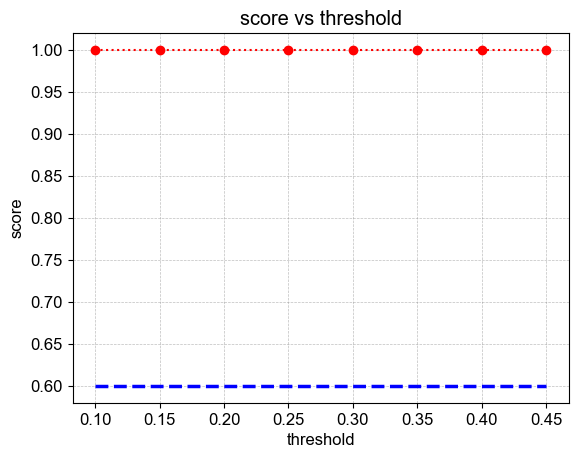

--------------------------------------------------
optimal_threshold: 0.45000000000000007
--------------------------------------------------
Identified model:
(x_1)' = 1.000 x_1dot
(x_1dot)' = -1.000 x_1 + 1.999 x_1dot + -0.500 x_2 + -1.999 x_1^2 x_1dot
(x_2)' = 1.000 x_2dot
(x_2dot)' = -0.500 x_1 + -1.000 x_2 + 1.999 x_2dot + -1.999 x_2^2 x_2dot


In [70]:
# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)

scores = []

threshold_start = 0.1
threshold_end = 0.5
threshold_step = 0.05

thresholds = np.arange(threshold_start, threshold_end, threshold_step)

for threshold in thresholds:
    opt = ps.STLSQ(threshold=threshold)
    model=ps.SINDy(differentiation_method=differentiation_method,
                   feature_library = feature_library,
                   feature_names=feature_names, 
                  optimizer=opt)
    model.fit(x_train,t=t_train)
    scores.append(model.score(x_train,t=t_train))

score_threshold = 0.6
threshold_line = np.ones(thresholds.shape) * score_threshold
plt.plot(thresholds, scores, 'ro:')
plt.plot(thresholds, threshold_line, 'b--', linewidth=2.5)
plt.xlabel('threshold')
plt.ylabel('score')
plt.title('score vs threshold')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.show()



optimal_threshold = None
for i in range(len(scores)):
    if scores[i] > score_threshold:
        optimal_threshold = thresholds[i]
    else:
        break

print('-'*50)
print(f'optimal_threshold: {optimal_threshold}')
print('-'*50)


# optimal_threshold = 4e-6 # for testing

if optimal_threshold is None:
    raise ValueError('No threshold found that gives a score > score_threshold')
else:
    opt = ps.STLSQ(threshold=optimal_threshold)
    model=ps.SINDy(differentiation_method=differentiation_method,
                    feature_library=feature_library,
                    feature_names=feature_names,
                    optimizer=opt)
    model.fit(x_train,t=t_train)
    print('Identified model:')
    model.print()


In [97]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

In [98]:
directory = case + '_coupling_non_custom'

if not os.path.exists(directory):
    os.makedirs(directory)

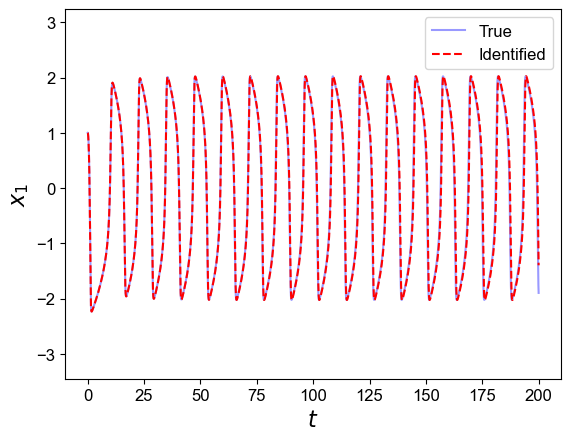

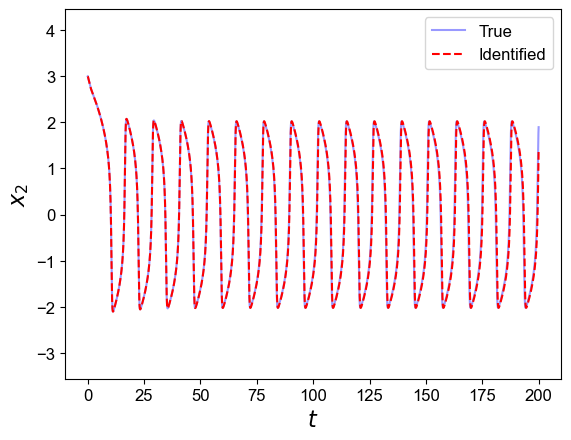

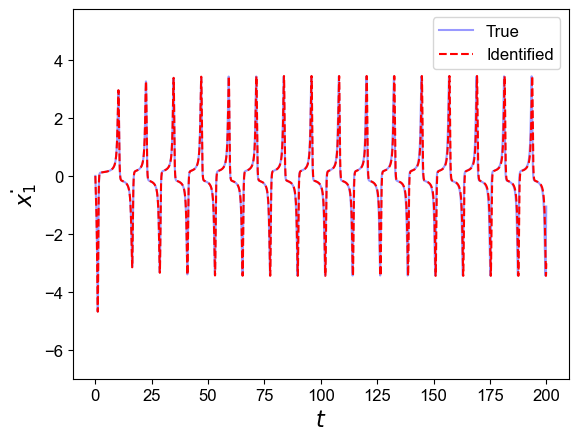

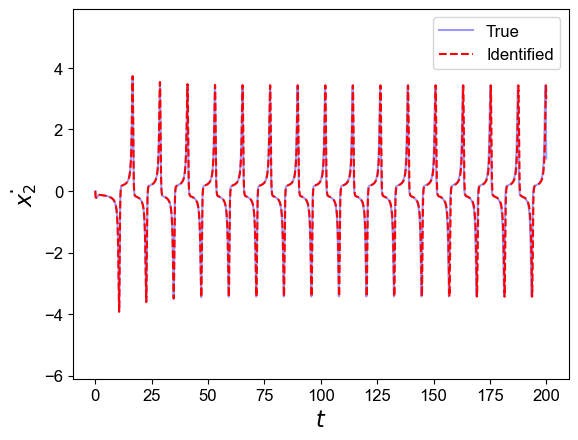

In [99]:
# plot the solution

plt.rcdefaults()
plt.rcParams.update({'font.size': 12})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# x1
plot_comparison(t, x[:,0], sim[:,0], "t", "x_1", "x1_coupled_vdp", directory=directory)

# x2
plot_comparison(t, x[:,2], sim[:,2], "t", "x_2", "x2_coupled_vdp",directory=directory)

# x1 dot
plot_comparison(t, x[:,1], sim[:,1], "t", "\dot{x_1}", "x1dot_coupled_vdp", directory=directory)

# x2 dot
plot_comparison(t, x[:,3], sim[:,3], "t", "\dot{x_2}", "x2dot_coupled_vdp", directory=directory)

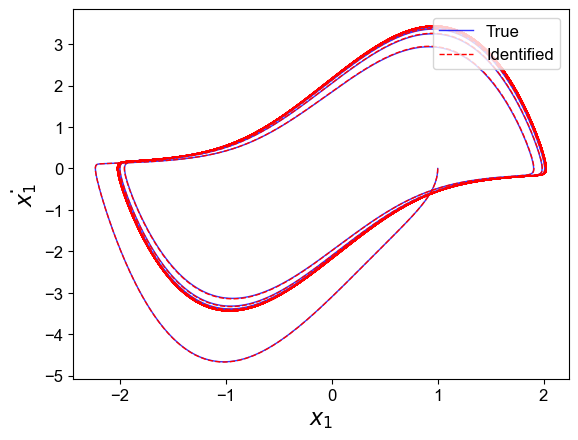

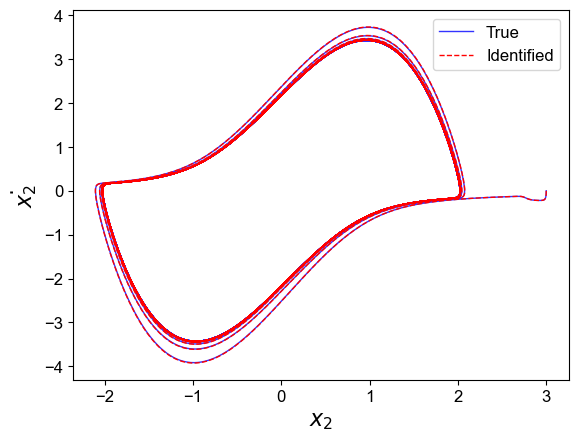

In [100]:
# Phase Portrait Oscillator 1
plot_pp(x[:,0], x[:,1], sim[:,0], sim[:,1], "x_1", "\dot{x_1}", "pp_x1_vdp", directory=directory)

# Phase Portrait Oscillator 2
plot_pp(x[:,2], x[:,3], sim[:,2], sim[:,3], "x_2", "\dot{x_2}", "pp_x2_vdp", directory=directory)

In [94]:
# plot 3d phase portrait
def plot_3d_pp(x,sim, t):
    fig = plt.figure(figsize=(10,10))
    ax = fig.gca(projection='3d')
    ax.plot(x[:n_points//2,0][:n_points//2], x[:n_points//2,1], t[:n_points//2], label='training')
    ax.plot(x[n_points//2:,0], x[n_points//2:,1], t[n_points//2:],'g', label='validation')
    ax.plot(sim[n_points//2:,0], sim[n_points//2:,1], t[n_points//2:],'r--' ,label='simulation')
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$\dot{x_1}$")
    ax.set_zlabel(r"$t$")
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('k')
    ax.yaxis.pane.set_edgecolor('k')
    ax.zaxis.pane.set_edgecolor('k')
    ax.legend()
    plt.title("3D Phase Portrait")
    plt.savefig(case + '_coupling_non_custom/' + case + '_3d_pp.png')
    plt.show()


C:\Users\wanik\AppData\Local\Temp\ipykernel_8912\2762017995.py:4: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


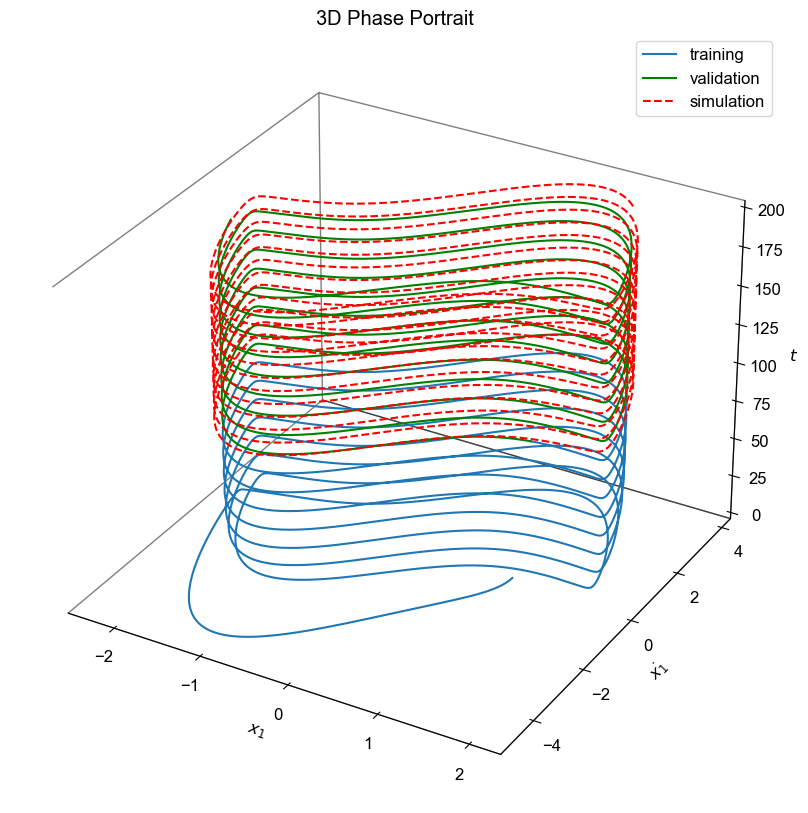

In [95]:
plot_3d_pp(x[:,:2],sim[:,:2],t)

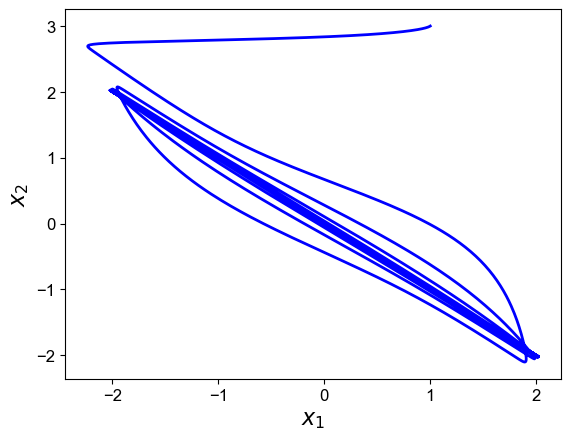

In [82]:
# Displacement Lissajous Figure
plot_lissajous(x[:,0], x[:,2], "x_1", "x_2", "lissajous_disp_vdp", directory=directory)

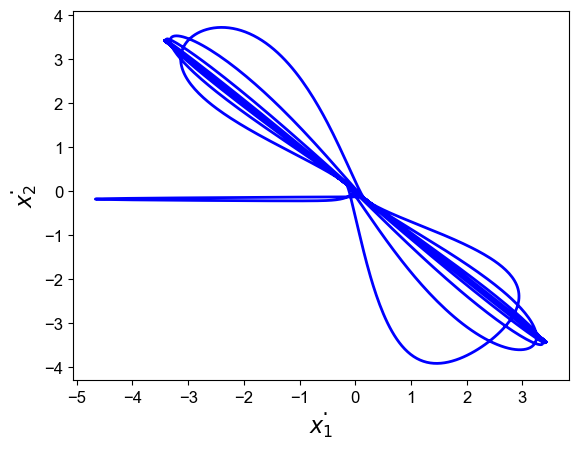

In [83]:
# Velocity Lissajous Figure
plot_lissajous(x[:,1], x[:,3], "\dot{x_1}", "\dot{x_2}", "lissajous_vel_vdp", directory=directory)